In [1]:
pip install pandas seaborn matplotlib gradio ollama

Defaulting to user installation because normal site-packages is not writeable
  Using cached aiofiles-24.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
  Using cached brotli-1.2.0-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached ffmpy-1.0.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached starlette-0.50.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached uvicorn-0.38.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-win_amd64.whl.metadata (5.0 kB)
  Using cached pydantic_core-2.41.5-cp313-cp313-win_amd64.whl.metadata (7.4 kB)
  Using cached typing

In [5]:
# By using EDA_LLM we are asking llm to generate insights by reading the dataset automatically 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url=r"C:\Users\sivap\OneDrive\Desktop\S\FSDS\December\Dec 19 2025\titanic_ dataset_final.csv"

In [3]:
df=pd.read_csv(url)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
# Display dataset info
print(df.describe())


       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
# Missing Value Check # \n is for new line
print("\nMissing Values:\n",df.isnull().sum())



Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


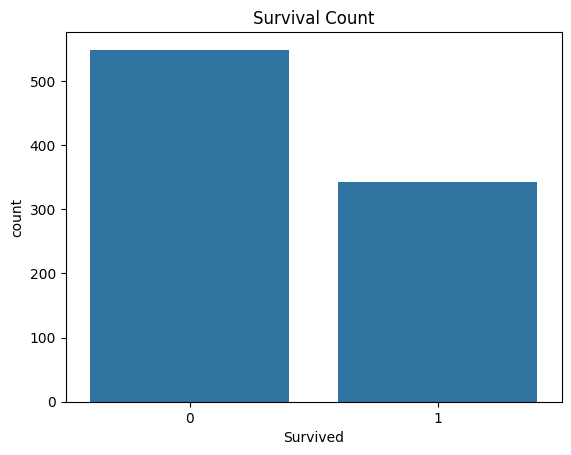

In [7]:
# Survival Rate Visuvalization
sns.countplot(x='Survived',data=df)
plt.title("Survival Count")
plt.show()

In [10]:
# I hava a dataset, i am passing that dataset to llm and summarise the content
# df_summary is an argument. 
# Prompt= fromatted string, how many variables you created that many curly braces you nedd to open


In [13]:
import ollama

def generate_insights(df_summary):
    prompt = f"Analyze the dataset summary and provide insights:\n\n{df_summary}"
    response = ollama.chat(model="gemma3:270m",messages=[{"role": "user", "content": prompt}])
    return response['message']['content']

# Generate AI Insights
summary = df.describe().to_string()
insights = generate_insights(summary)
print("\n🔹 AI-Generated Insights:\n", insights)


🔹 AI-Generated Insights:
 Here's an analysis of the dataset summary, highlighting key insights:

**Overall Impression:**

The dataset summary indicates a moderately high number of observations, suggesting that the dataset is relatively well-structured and contains a good amount of data. However, there are potential areas for improvement in terms of data quality, potential biases, and potential inaccuracies.

**Key Observations:**

*   **High Number of Observations:** The dataset has a significant number of observations (891). This suggests a relatively high level of data collection and analysis.
*   **Good Mean and Standard Deviation:** The mean and standard deviation values for the number of observations are within a reasonable range. This indicates that the data is collected and analyzed effectively.
*   **Minimizing 25%:** The minimum number of observations is 25%. This suggests that the dataset is likely to be relatively small, potentially leading to under-representation of certai

In [16]:
# Creating Frontend
# After Executing Below code it will ask you to select file for analysis select any dataset from your folders and submit

In [17]:
import gradio as gr

def eda_analysis(file):
    df=pd.read_csv(file.name)
    summary=df.describe().to_string()
    insights=generate_insights(summary)
    return insights

# create web interface
demo=gr.Interface(fn=eda_analysis,inputs="file",outputs="text",title="AI Powered EDA with Gemma By Siva Pulikonda")

# launch app
demo.launch(share=True) # Use Share True For google collab



* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://ed26ddc7abdf33eaa8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
# If i deploy this local host to godaddy we can build our own websites and anyone can use it